In [2]:
import os
import glob
import sys
sys.path.append('/Users/aghavamp/Desktop/Projects')
sys.path.append('/Users/aghavamp/Desktop/Projects/bimanual_wrist')
sys.path.append('/Users/aghavamp/Desktop/Projects/Functional_Fusion')
sys.path.append('/Users/aghavamp/Desktop/Projects/PcmPy')
import getpass
import importlib
from tqdm import tqdm
from pathlib import Path

from rsatoolbox.io import spm as spm_io
import surfAnalysisPy as surf
import SUITPy as suit
import nibabel as nb
import nitools as nt
import PcmPy as pcm
import Functional_Fusion.atlas_map as am
import Functional_Fusion.reliability as rel

import matplotlib.pyplot as plt
import matplotlib
from matplotlib.cm import ScalarMappable
import matplotlib.cm as cm
import matplotlib.colors as mcolors
import matplotlib.patches as patches
import seaborn as sns

import scipy.io as sio
import numpy as np
import pandas as pd

import utils
importlib.reload(utils)

# SET PATHS:
baseDir = os.path.join('/Users', getpass.getuser(), 'Desktop', 'Projects', 'bimanual_wrist', 'data', 'fMRI')
bidsDir = 'BIDS'
anatomicalDir = 'anatomicals'
freesurferDir = 'surfaceFreesurfer'
surfacewbDir = 'surfaceWB' 
behavDir = 'behavioural'
regDir = 'ROI'
atlasDir = '/Volumes/diedrichsen_data$/data/Atlas_templates/fs_LR_32'
analysisDir = os.path.join(os.path.dirname(os.path.dirname(baseDir)), 'analysis')



## 6 by 6 unimanual matrix

In [6]:
regions = ['PMd','PMv','M1','S1','SMA','SPLa','SPLp']

G_uni = {'region':[], 'G_uni':[]}
for region in regions:
    # load unimanual G matrix:
    D = np.load(os.path.join(analysisDir, f'pcm_dataset_6by6_{region}.npz'), allow_pickle=True)
    
    # estimate cross-val G matrix:
    N = len(D['Y'])
    G_hat = np.zeros((N, 6, 6))
    for i in range(N):
        G_hat[i,:,:], _ = pcm.est_G_crossval(D['Y'][i].measurements,
                                          D['Y'][i].obs_descriptors['cond_vec'],
                                          D['Y'][i].obs_descriptors['part_vec'],
                                          X=pcm.matrix.indicator(D['Y'][i].obs_descriptors['part_vec']))
    G_uni['region'].append(region)
    G_uni['G_uni'].append(G_hat)

# after the loop
G_uni_df = pd.DataFrame({
    'region': G_uni['region'],
    'G_hat': G_uni['G_uni'],   # list of (N, 6, 6) arrays
})

G_uni_df.to_pickle(os.path.join(analysisDir, 'G_uni.pkl'))



## 48 by 48 distance matrix

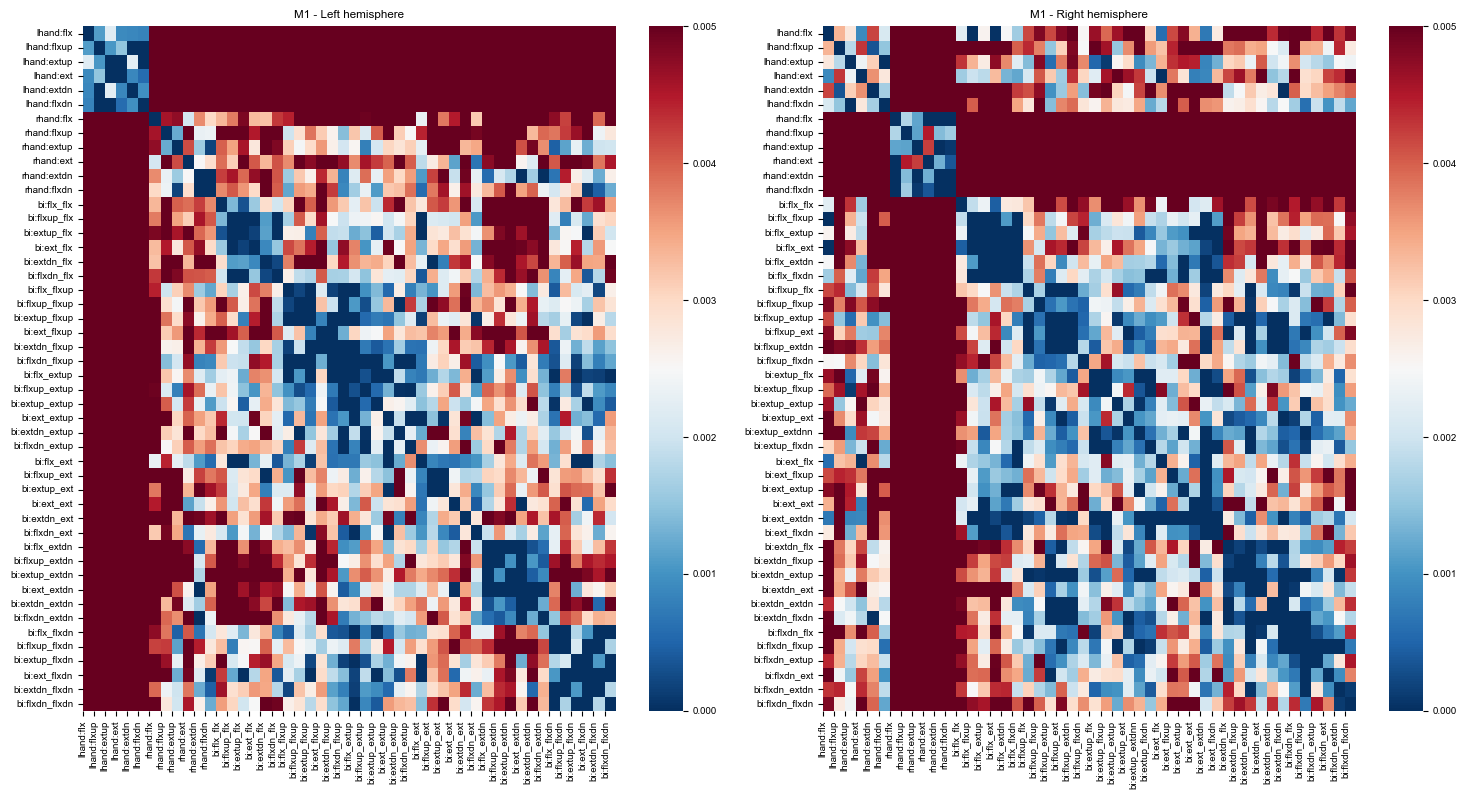

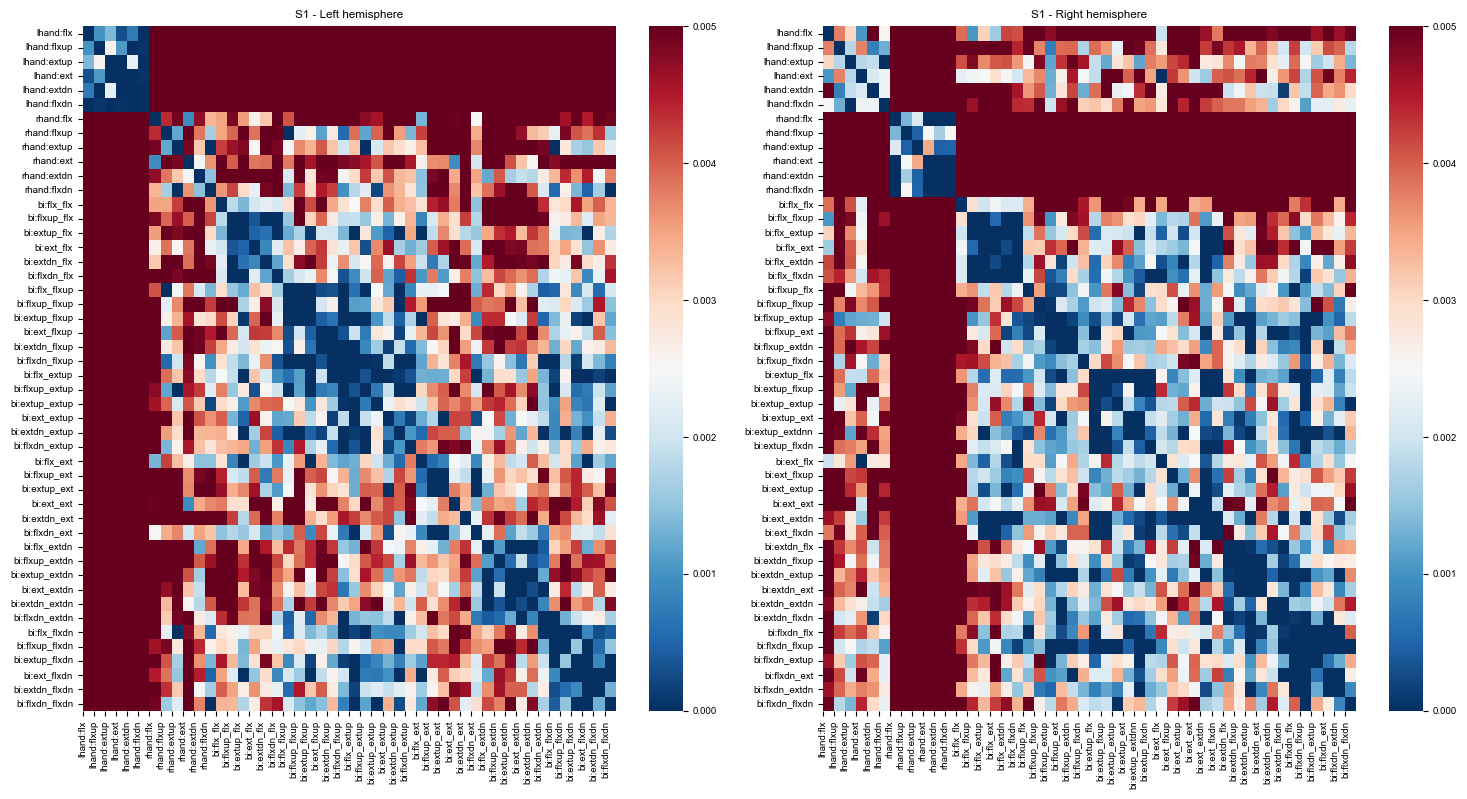

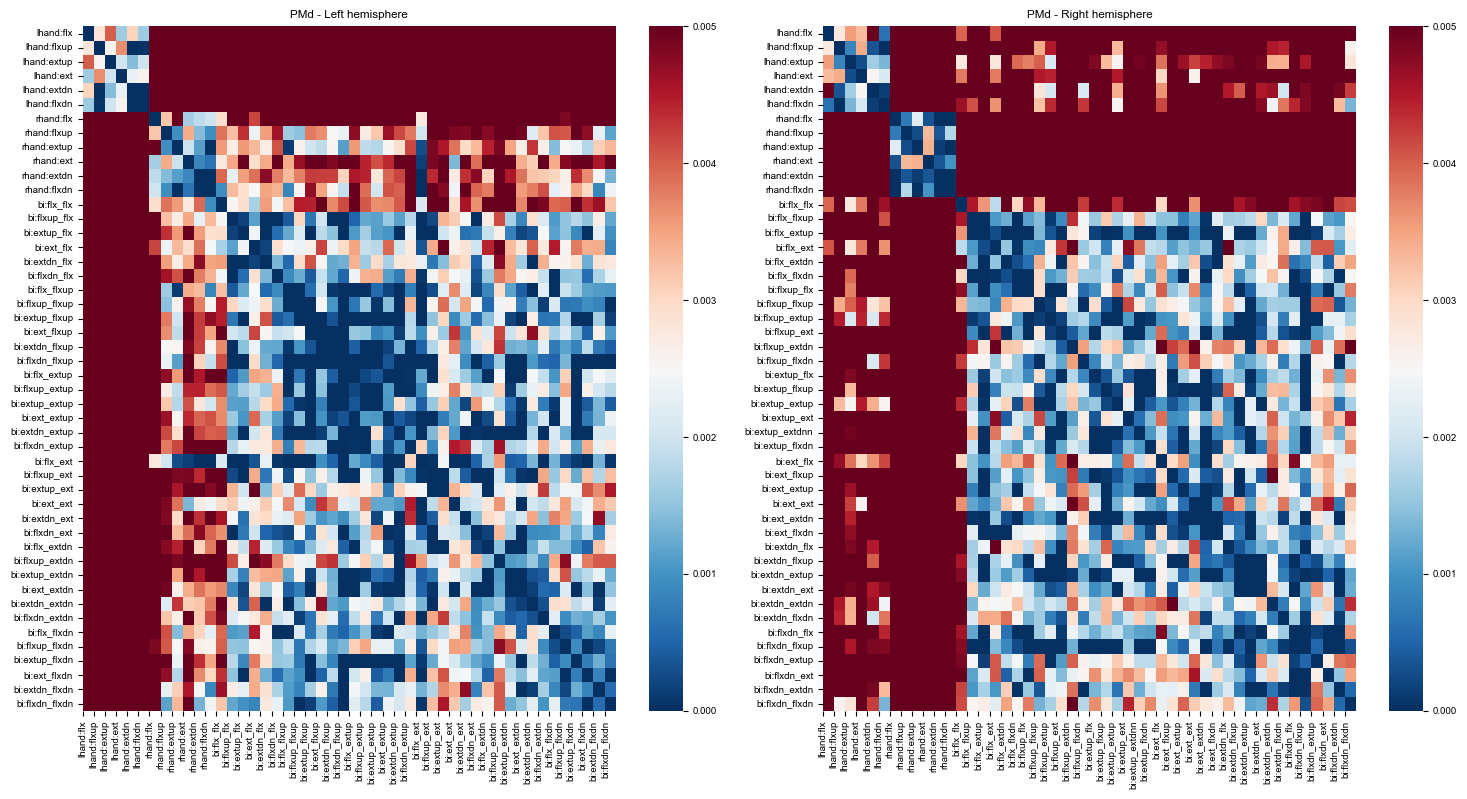

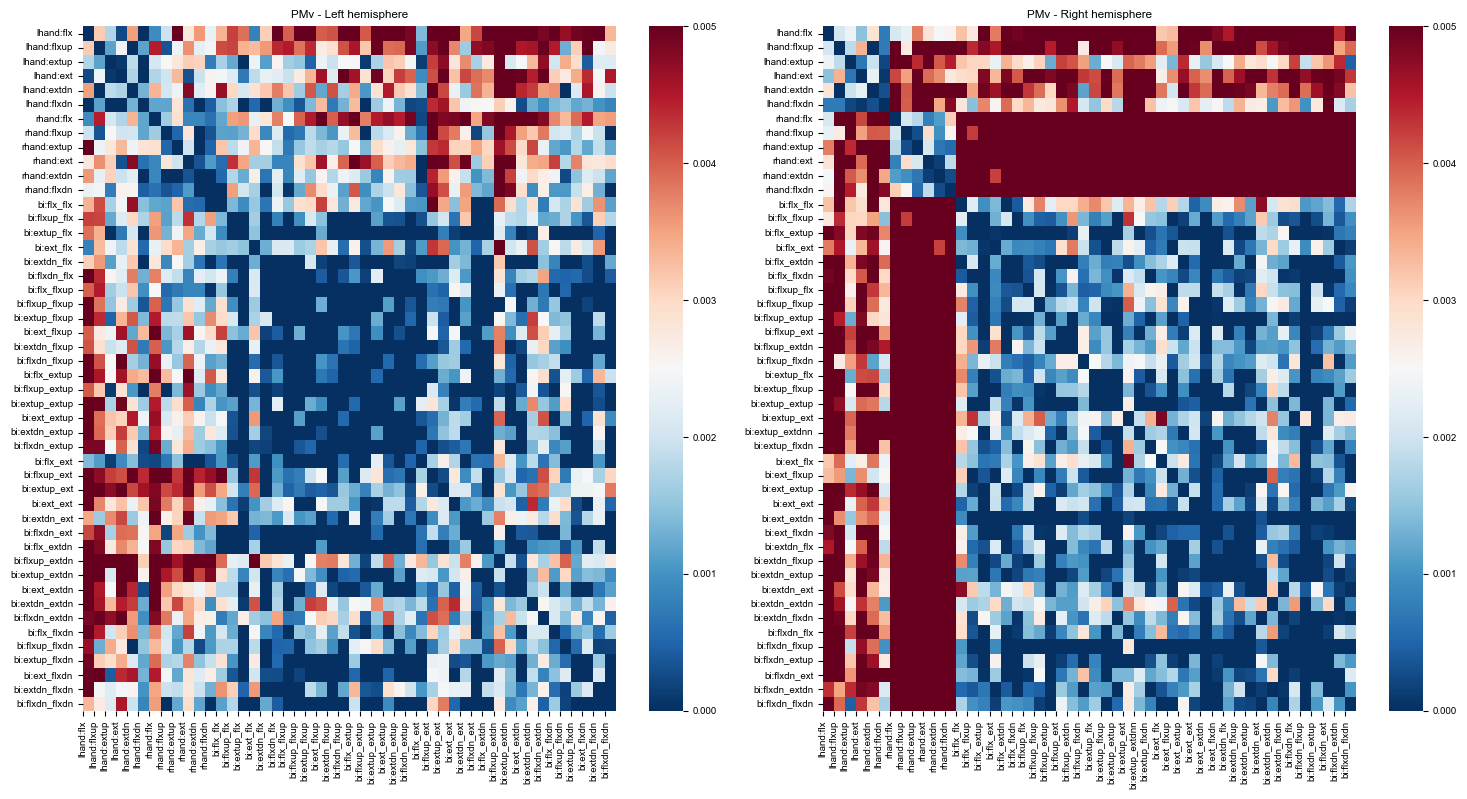

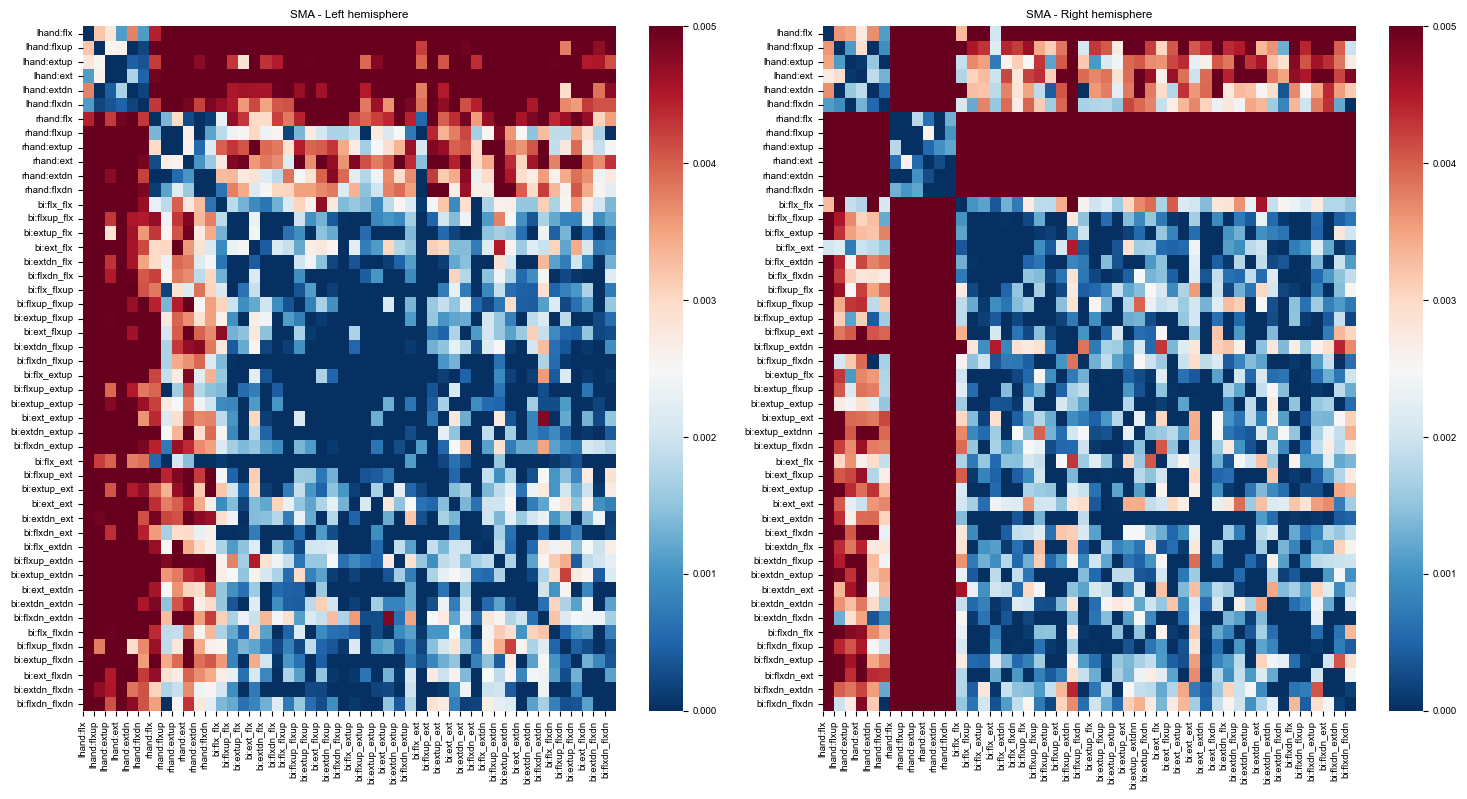

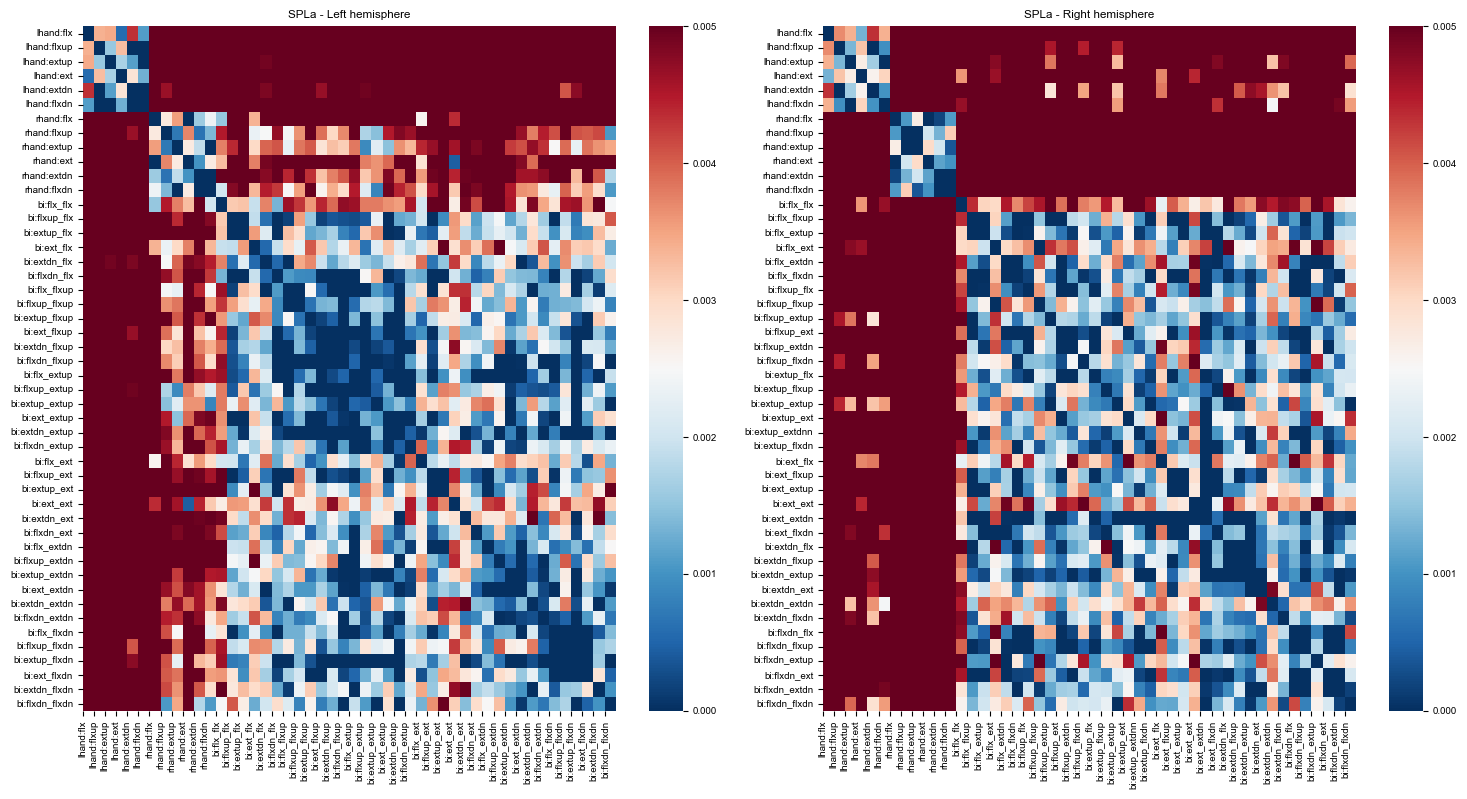

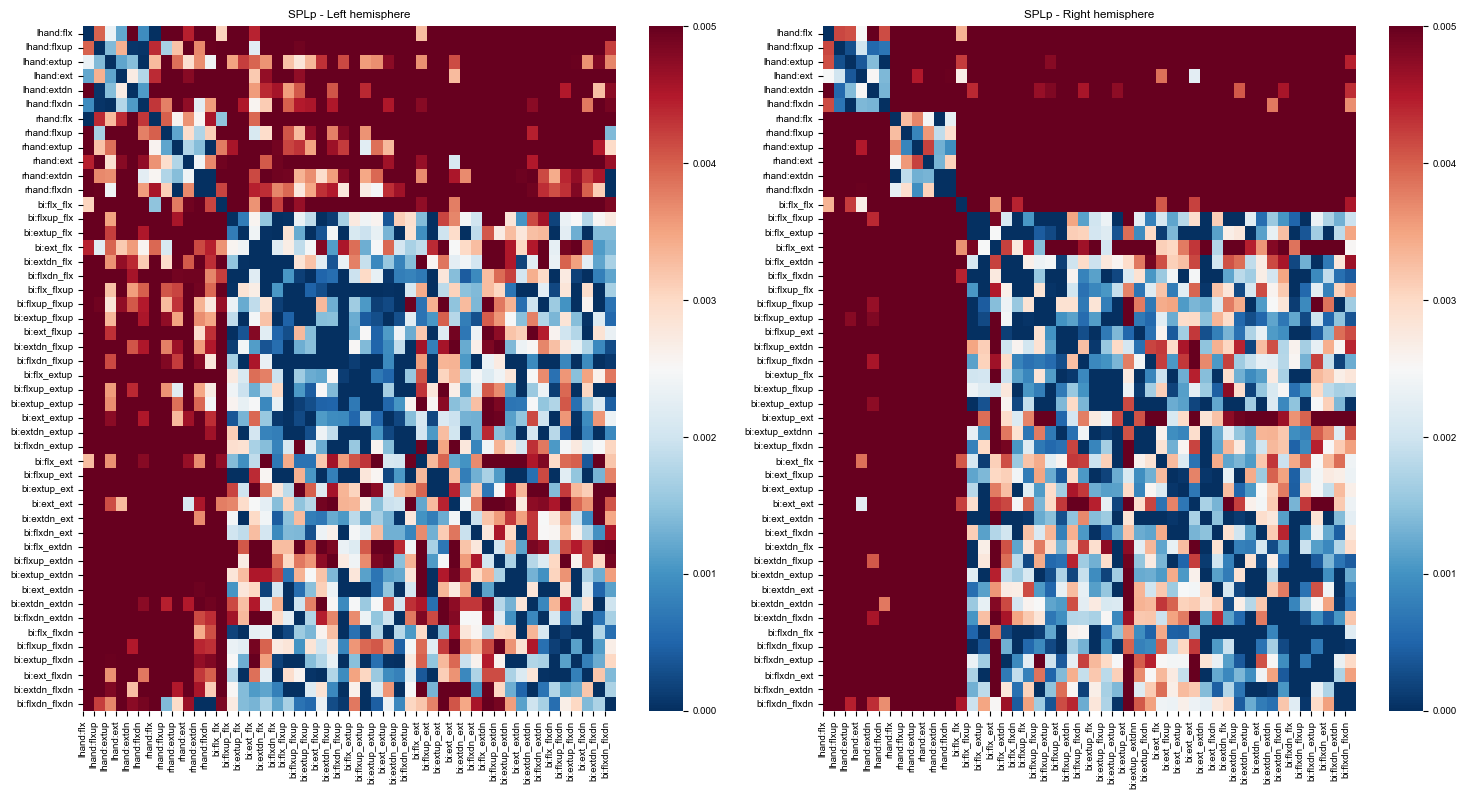

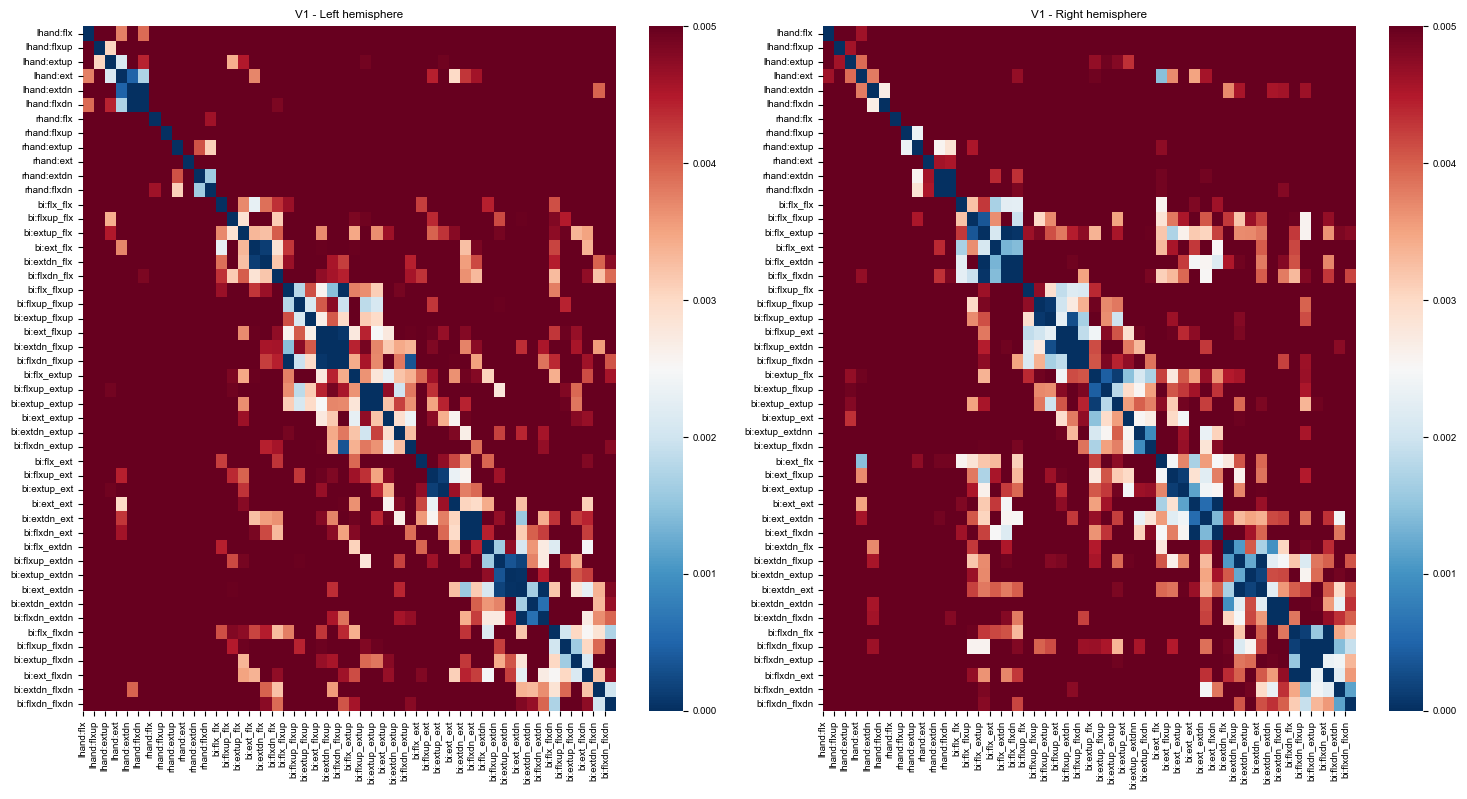

In [25]:
labels = {'L': ['lhand:flx',     'lhand:flxup',    'lhand:extup',    'lhand:ext',    'lhand:extdn',    'lhand:flxdn',
                'rhand:flx',     'rhand:flxup',    'rhand:extup',    'rhand:ext',    'rhand:extdn',    'rhand:flxdn',
                'bi:flx_flx', 'bi:flxup_flx', 'bi:extup_flx', 'bi:ext_flx', 'bi:extdn_flx', 'bi:flxdn_flx', 
                'bi:flx_flxup', 'bi:flxup_flxup', 'bi:extup_flxup', 'bi:ext_flxup', 'bi:extdn_flxup', 'bi:flxdn_flxup', 
                'bi:flx_extup', 'bi:flxup_extup', 'bi:extup_extup', 'bi:ext_extup', 'bi:extdn_extup', 'bi:flxdn_extup', 
                'bi:flx_ext', 'bi:flxup_ext', 'bi:extup_ext', 'bi:ext_ext', 'bi:extdn_ext', 'bi:flxdn_ext', 
                'bi:flx_extdn', 'bi:flxup_extdn', 'bi:extup_extdn', 'bi:ext_extdn', 'bi:extdn_extdn', 'bi:flxdn_extdn', 
                'bi:flx_flxdn', 'bi:flxup_flxdn', 'bi:extup_flxdn', 'bi:ext_flxdn', 'bi:extdn_flxdn', 'bi:flxdn_flxdn' ],

          'R': ['lhand:flx',     'lhand:flxup',    'lhand:extup',    'lhand:ext',    'lhand:extdn',    'lhand:flxdn',
                'rhand:flx',     'rhand:flxup',    'rhand:extup',    'rhand:ext',    'rhand:extdn',    'rhand:flxdn',
                'bi:flx_flx',    'bi:flx_flxup',   'bi:flx_extup',   'bi:flx_ext',   'bi:flx_extdn',   'bi:flx_flxdn',
                'bi:flxup_flx',  'bi:flxup_flxup', 'bi:flxup_extup', 'bi:flxup_ext', 'bi:flxup_extdn', 'bi:flxup_flxdn',
                'bi:extup_flx',  'bi:extup_flxup', 'bi:extup_extup', 'bi:extup_ext', 'bi:extup_extdnn', 'bi:extup_flxdn',
                'bi:ext_flx',    'bi:ext_flxup',   'bi:ext_extup',   'bi:ext_ext',   'bi:ext_extdn',   'bi:ext_flxdn',
                'bi:extdn_flx',  'bi:extdn_flxup', 'bi:extdn_extup', 'bi:extdn_ext', 'bi:extdn_extdn', 'bi:extdn_flxdn',
                'bi:flxdn_flx',  'bi:flxdn_flxup', 'bi:flxdn_extup', 'bi:flxdn_ext', 'bi:flxdn_extdn', 'bi:flxdn_flxdn']
}

cmap = 'RdBu_r'
sn_bad = []
regions = ['M1','S1','PMd','PMv','SMA','SPLa','SPLp','V1']
df = {'sn':[], 'roi':[], 'type':[], 'hem':[], 'd2':[], 'd':[]}
plt.rcParams['font.family'] = 'Arial'
plt.rcParams['font.size'] = 7
# loop on region:
for i_region, region in enumerate(regions):
    # load pcm dataset:
    D = np.load(os.path.join(analysisDir, f'pcm_dataset_allconds_{region}.npz'), allow_pickle=True)

    Y = D['Y']
    cond_vec = D['cond_vec']
    part_vec = D['part_vec']
    hemisphere = D['hemisphere']

    N = len(Y)
    ncond = 48
    G_hat = np.zeros((N, ncond, ncond))
    RDM = np.zeros((N, ncond, ncond))
    for i_sub in range(N):
        G_hat[i_sub, :, :], _ = pcm.est_G_crossval(Y[i_sub].measurements,
                                                   Y[i_sub].obs_descriptors['cond_vec'],
                                                   Y[i_sub].obs_descriptors['part_vec'],
                                                   X=pcm.matrix.indicator(Y[i_sub].obs_descriptors['part_vec']))

        tmp_D2 = pcm.G_to_dist(G_hat[i_sub, :, :])
        # transform to distance:
        RDM[i_sub, :, :] = np.sqrt(np.abs(tmp_D2)) * np.sign(tmp_D2)

        # contralateral and ipsilateral conditions:
        if hemisphere[i_sub] == 'L':
            idx_contra = np.array([6,7,8,9,10,11])
            idx_ipsi = np.array([0,1,2,3,4,5])
        elif hemisphere[i_sub] == 'R':
            idx_contra = np.array([0,1,2,3,4,5])
            idx_ipsi = np.array([6,7,8,9,10,11])
        idx_bimanual = np.arange(12,48)

        # average distances:
        contra_d2 = tmp_D2[np.ix_(idx_contra, idx_contra)]
        tmp_d2 = np.sum(contra_d2) / (6*5)
        tmp_d = np.sign(tmp_d2) * np.sqrt(np.abs(tmp_d2))
        df['sn'].append(i_sub)
        df['roi'].append(region)
        df['type'].append('contra')
        df['hem'].append(hemisphere[i_sub])
        df['d2'].append(tmp_d2)
        df['d'].append(tmp_d)

        ipsi_d2 = tmp_D2[np.ix_(idx_ipsi, idx_ipsi)]
        tmp_d2 = np.sum(ipsi_d2) / (6*5)
        tmp_d = np.sign(tmp_d2) * np.sqrt(np.abs(tmp_d2))
        df['sn'].append(i_sub)
        df['roi'].append(region)
        df['type'].append('ipsi')
        df['hem'].append(hemisphere[i_sub])
        df['d2'].append(tmp_d2)
        df['d'].append(tmp_d)

        bimanual_d2 = tmp_D2[np.ix_(idx_bimanual, idx_bimanual)]
        tmp_d2 = np.sum(bimanual_d2) / (36*35)
        tmp_d = np.sign(tmp_d2) * np.sqrt(np.abs(tmp_d2))
        df['sn'].append(i_sub)
        df['roi'].append(region)
        df['type'].append('bi')
        df['hem'].append(hemisphere[i_sub])
        df['d2'].append(tmp_d2)
        df['d'].append(tmp_d)

    idx_L = hemisphere == 'L'
    idx_R = hemisphere == 'R'
    RDM_avg_L = np.mean(RDM[idx_L,:,:], axis=0)
    RDM_avg_R = np.mean(RDM[idx_R,:,:], axis=0)

    fig, axes = plt.subplots(1, 2, figsize=(15,8))
    vmin = 0
    vmax = 5e-3
    sns.heatmap(RDM_avg_L, ax=axes[0], cmap=cmap, vmin=0, vmax=vmax)
    sns.heatmap(RDM_avg_R, ax=axes[1], cmap=cmap, vmin=0, vmax=vmax)
    axes[0].set_title(f'{region} - Left hemisphere')
    axes[0].set_xticks(np.arange(0,48,1))
    axes[0].set_xticklabels(labels['L'], rotation=90)
    axes[0].set_yticklabels(labels['L'], rotation=0)
    axes[1].set_title(f'{region} - Right hemisphere')
    axes[1].set_xticks(np.arange(0,48,1))
    axes[1].set_xticklabels(labels['R'], rotation=90)
    axes[1].set_yticklabels(labels['R'], rotation=0)
    plt.tight_layout()
    plt.show()



### plot distances 

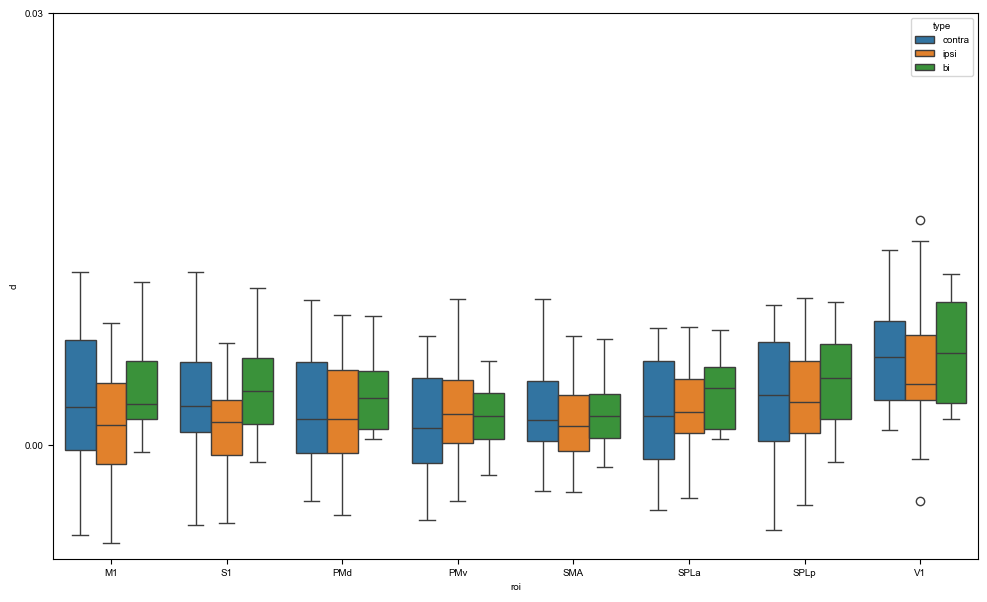

In [28]:
fig, ax = plt.subplots(figsize=(10,6))
sns.boxplot(data=df, x='roi', y='d', hue='type', ax=ax)
plt.tight_layout()
# plt.ylim((-0.008,0.015))
plt.yticks([0, 0.03])
plt.show()
